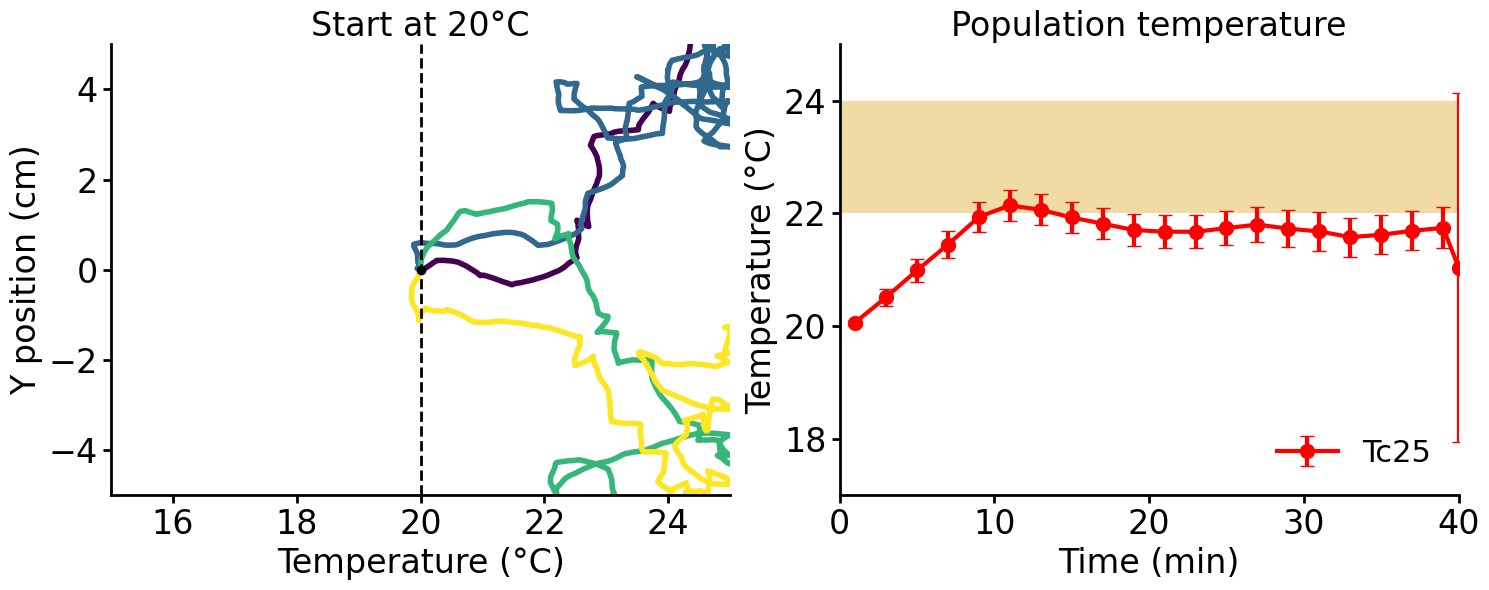

In [5]:
# ============================================================
# Minimal AFD-grounded thermotaxis simulation
# Start at 20°C only
# Generates a clean 1x2 panel:
#   1) example tracks
#   2) population temperature over time
# ============================================================

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import gamma as scipy_gamma

mpl.rcParams["svg.fonttype"] = "none"

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(10)

# ============================================================
# Save figure settings
# ============================================================
save_fig = False
save_folder = "path_to_folder/"   # <-- change to your path

# ============================================================
# Global settings
# ============================================================
N_WORMS = 500
TOTAL_TIME_S = 2400
DT = 1.0
N_STEPS = int(TOTAL_TIME_S / DT)
N_SHOW = 4
user_bin_minutes = 2

# ============================================================
# Plot settings
# ============================================================
AXIS_LABEL_FONTSIZE = 24
TICK_LABEL_FONTSIZE = 24
TITLE_FONTSIZE = 24
LEGEND_FONTSIZE = 22

TRACK_LINEWIDTH = 4.0
TRACK_ALPHA = 1.0
START_DOT_SIZE = 6
VLINE_WIDTH = 2.0
SPINE_WIDTH = 2.0
TICK_WIDTH = 2.0
TICK_LENGTH = 6

# ============================================================
# AFD model parameters
# ============================================================
T_ON = 22.04
K_SHAPE = 1.52
K_SCALE = 2.52
TAU_D_S = 58.93

if K_SHAPE > 1:
    T_PEAK_REL = (K_SHAPE - 1.0) * K_SCALE
else:
    T_PEAK_REL = 0.0

W_PEAK = scipy_gamma.pdf(T_PEAK_REL, a=K_SHAPE, scale=K_SCALE)

# ============================================================
# Gain parameters
# ============================================================
GAIN_CUTOFF_TEMP = 19.5
TAIL_SCALE = 2.0
TAIL_WEIGHT = 0.30

# ============================================================
# Assay definition: steep gradient
# ============================================================
STEEP_ASSAY_BASE = {
    "L": 10.0,
    "W": 10.0,
    "T_left": 15.0,
    "T_right": 25.0,
    "T_split": 22.5,
    "speed_cm_s": 0.016,
    "mean_run_s": 20.0,
    "within_run_jitter_deg": 3.5,
    "title": "Steep gradient"
}

# ============================================================
# Behavioral parameters
# ============================================================
D0 = 0.0055
SIGMA_DECISION = 0.001

KAPPA_DIR_MIN = 1.5
KAPPA_DIR_MAX = 8.0
KAPPA_ISO = 85.0
EXPLORATORY_KAPPA = 2.5

ISO_SIDE_PERSIST = 0.985
P_EXIT_AT_BOUNDARY = 0.1

DIR_DRIVE_SCALE = 0.002

# ============================================================
# Helper functions
# ============================================================
def wrap_deg_360(a):
    return a % 360.0

def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

def temp_from_x(x, assay):
    return assay["T_left"] + (assay["T_right"] - assay["T_left"]) * (x / assay["L"])

def x_from_temp(T, assay):
    return assay["L"] * (T - assay["T_left"]) / (assay["T_right"] - assay["T_left"])

def sample_vonmises_deg(mu_deg, kappa):
    return wrap_deg_360(np.rad2deg(np.random.vonmises(np.deg2rad(mu_deg), kappa)))

def circ_mean_deg(theta_deg):
    theta_deg = np.asarray(theta_deg, dtype=float)
    theta_deg = theta_deg[np.isfinite(theta_deg)]
    if theta_deg.size == 0:
        return np.nan
    th = np.deg2rad(theta_deg)
    return np.rad2deg(np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th))))

def one_pole_update(prev, target, dt, tau):
    alpha = 1.0 - np.exp(-dt / tau)
    return prev + alpha * (target - prev)

def is_outside_plate(x, y, assay):
    return (x < 0) or (x > assay["L"]) or (y < -assay["W"] / 2) or (y > assay["W"] / 2)

def nearest_edge(x, y, assay):
    d_left = abs(x - 0.0)
    d_right = abs(assay["L"] - x)
    d_bottom = abs(y + assay["W"] / 2.0)
    d_top = abs(assay["W"] / 2.0 - y)
    dmin = min(d_left, d_right, d_bottom, d_top)
    if dmin == d_left:
        return "left"
    elif dmin == d_right:
        return "right"
    elif dmin == d_bottom:
        return "bottom"
    else:
        return "top"

def calculate_heading_and_distance(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    dx = np.diff(x)
    dy = np.diff(y)
    heading_deg = wrap_deg_360(np.rad2deg(np.arctan2(dy, dx)))
    distance = np.sqrt(dx**2 + dy**2)
    return heading_deg, distance

def summarize_single_run(x_run, y_run, dt, start_temperature, min_run_seconds=5.0):
    x_run = np.asarray(x_run, dtype=float)
    y_run = np.asarray(y_run, dtype=float)

    valid = np.isfinite(x_run) & np.isfinite(y_run)
    x_run = x_run[valid]
    y_run = y_run[valid]

    if x_run.size < 2:
        return None

    run_duration = (x_run.size - 1) * dt
    if run_duration < min_run_seconds:
        return None

    heading_steps, distance_steps = calculate_heading_and_distance(x_run, y_run)
    mean_heading_run = circ_mean_deg(heading_steps)
    run_distance = np.nansum(distance_steps)

    return {
        "heading_deg": wrap_deg_360(mean_heading_run),
        "distance": run_distance,
        "duration_s": run_duration,
        "start_temperature": float(start_temperature),
    }

# ============================================================
# AFD gain and drive
# ============================================================
def compute_temp_gate(T_now):
    if T_now < GAIN_CUTOFF_TEMP:
        return 0.0

    T_rel = T_now - T_ON

    if T_rel < 0:
        return TAIL_WEIGHT * np.exp(T_rel / TAIL_SCALE)

    W = scipy_gamma.pdf(T_rel, a=K_SHAPE, scale=K_SCALE)
    return W / (W_PEAK + 1e-9)

def compute_behavioral_drive(D_state, T_now):
    return compute_temp_gate(T_now) * D_state

# ============================================================
# Heading choice
# ============================================================
def choose_heading(T_now, D_state, iso_sign, prev_heading_deg, assay):
    gate = compute_temp_gate(T_now)
    drive = compute_behavioral_drive(D_state, T_now)

    p_iso = logistic((drive - D0) / SIGMA_DECISION)

    if np.random.rand() > ISO_SIDE_PERSIST:
        iso_sign *= -1

    if np.random.rand() < p_iso:
        mu_deg = 90.0 if iso_sign > 0 else 270.0
        heading_deg = sample_vonmises_deg(mu_deg, KAPPA_ISO)
        in_iso_mode = True
        warm_bias_strength = 0.0

    else:
        positive_drive = max(drive, 0.0)
        warm_bias_strength = np.clip(positive_drive / DIR_DRIVE_SCALE, 0.0, 1.0)

        prev_vec = np.array([
            np.cos(np.deg2rad(prev_heading_deg)),
            np.sin(np.deg2rad(prev_heading_deg))
        ])
        warm_vec = np.array([1.0, 0.0])

        blended_vec = (1.0 - warm_bias_strength) * prev_vec + warm_bias_strength * warm_vec

        if np.allclose(blended_vec, 0.0):
            mu_deg = prev_heading_deg
        else:
            mu_deg = wrap_deg_360(np.rad2deg(np.arctan2(blended_vec[1], blended_vec[0])))

        kappa_dir = KAPPA_DIR_MIN + (KAPPA_DIR_MAX - KAPPA_DIR_MIN) * warm_bias_strength
        kappa_dir = np.clip(kappa_dir, KAPPA_DIR_MIN, KAPPA_DIR_MAX)

        if warm_bias_strength < 0.05:
            heading_deg = sample_vonmises_deg(prev_heading_deg, EXPLORATORY_KAPPA)
        else:
            heading_deg = sample_vonmises_deg(mu_deg, kappa_dir)

        in_iso_mode = False

    return heading_deg, iso_sign, p_iso, drive, in_iso_mode, gate, warm_bias_strength

# ============================================================
# Boundary return rule
# ============================================================
def choose_boundary_return_heading(x, y, assay, was_in_iso_mode, iso_sign):
    edge = nearest_edge(x, y, assay)

    if was_in_iso_mode and edge in ("top", "bottom"):
        mu = 270.0 if edge == "top" else 90.0
        return sample_vonmises_deg(mu, KAPPA_ISO), iso_sign

    if edge == "left":
        mu = 0.0
    elif edge == "right":
        mu = 180.0
    elif edge == "top":
        mu = 270.0
    else:
        mu = 90.0

    return sample_vonmises_deg(mu, KAPPA_DIR_MAX), iso_sign

# ============================================================
# Run-summary bookkeeping
# ============================================================
def finalize_run_and_store(run_x, run_y, run_start_temperature, assay, runs_all, runs_r1, runs_r2):
    summary = summarize_single_run(
        run_x, run_y, dt=DT, start_temperature=run_start_temperature, min_run_seconds=5.0
    )
    if summary is None:
        return

    summary["regime"] = 1 if summary["start_temperature"] < assay["T_split"] else 2
    runs_all.append(summary)
    if summary["regime"] == 1:
        runs_r1.append(summary)
    else:
        runs_r2.append(summary)

def choose_initial_heading():
    return np.random.uniform(0.0, 360.0)

# ============================================================
# Main simulation
# ============================================================
def simulate_assay_from_config(assay):
    speed_cm_s = assay["speed_cm_s"]
    mean_run_s = assay["mean_run_s"]
    within_run_jitter_deg = assay["within_run_jitter_deg"]

    x0 = x_from_temp(assay["T_start"], assay)
    y0 = 0.0

    tracks = []
    run_summaries_all = []
    run_summaries_r1 = []
    run_summaries_r2 = []
    exited_flags = []

    for _ in range(N_WORMS):
        x, y = x0, y0
        T_now = temp_from_x(x, assay)
        T_prev = T_now
        D_state = 0.0
        iso_sign = np.random.choice([-1, 1])

        prev_heading_deg = choose_initial_heading()
        heading_deg = prev_heading_deg
        in_iso_mode = False
        run_left = max(1, int(np.random.exponential(mean_run_s)))

        current_run_x = [x]
        current_run_y = [y]
        current_run_start_temperature = T_now

        xs = [x]
        ys = [y]
        exited = False

        for _t in range(1, N_STEPS + 1):
            T_now = temp_from_x(x, assay)

            dT_raw = (T_now - T_prev) / DT
            T_prev = T_now
            D_state = one_pole_update(D_state, dT_raw, DT, TAU_D_S)

            if run_left <= 0:
                finalize_run_and_store(
                    current_run_x, current_run_y, current_run_start_temperature,
                    assay, run_summaries_all, run_summaries_r1, run_summaries_r2
                )

                prev_heading_deg = heading_deg
                heading_deg, iso_sign, _, _, in_iso_mode, _, _ = choose_heading(
                    T_now, D_state, iso_sign, prev_heading_deg, assay
                )
                run_left = max(1, int(np.random.exponential(mean_run_s)))

                current_run_x = [x]
                current_run_y = [y]
                current_run_start_temperature = T_now

            heading_deg = wrap_deg_360(
                heading_deg + np.random.normal(0.0, within_run_jitter_deg)
            )

            x_new = x + speed_cm_s * DT * np.cos(np.deg2rad(heading_deg))
            y_new = y + speed_cm_s * DT * np.sin(np.deg2rad(heading_deg))

            if is_outside_plate(x_new, y_new, assay):
                if np.random.rand() < P_EXIT_AT_BOUNDARY:
                    finalize_run_and_store(
                        current_run_x, current_run_y, current_run_start_temperature,
                        assay, run_summaries_all, run_summaries_r1, run_summaries_r2
                    )
                    exited = True
                    break
                else:
                    finalize_run_and_store(
                        current_run_x, current_run_y, current_run_start_temperature,
                        assay, run_summaries_all, run_summaries_r1, run_summaries_r2
                    )

                    heading_deg, iso_sign = choose_boundary_return_heading(
                        x, y, assay, was_in_iso_mode=in_iso_mode, iso_sign=iso_sign
                    )

                    run_left = max(1, int(np.random.exponential(mean_run_s)))
                    current_run_x = [x]
                    current_run_y = [y]
                    current_run_start_temperature = temp_from_x(x, assay)
                    continue

            x, y = x_new, y_new
            xs.append(x)
            ys.append(y)

            current_run_x.append(x)
            current_run_y.append(y)

            run_left -= 1

        if not exited:
            finalize_run_and_store(
                current_run_x, current_run_y, current_run_start_temperature,
                assay, run_summaries_all, run_summaries_r1, run_summaries_r2
            )

        tracks.append({
            "x": np.array(xs),
            "y": np.array(ys),
            "x0": x0,
            "y0": y0,
        })
        exited_flags.append(exited)

    return {
        "tracks": tracks,
        "runs_all": run_summaries_all,
        "runs_r1": run_summaries_r1,
        "runs_r2": run_summaries_r2,
        "assay": assay,
        "x0": x0,
        "y0": y0,
        "exited_flags": np.array(exited_flags, dtype=bool),
    }

# ============================================================
# Temperature-vs-time summary
# ============================================================
def get_temp_time_summary(res, bin_minutes=user_bin_minutes):
    assay = res["assay"]
    tracks = res["tracks"]

    n_worms = len(tracks)
    max_len = max(len(tr["x"]) for tr in tracks)

    temp_mat = np.full((n_worms, max_len), np.nan)

    for i, tr in enumerate(tracks):
        x_vals = np.asarray(tr["x"], dtype=float)
        temp_vals = temp_from_x(x_vals, assay)
        temp_mat[i, :len(temp_vals)] = temp_vals

    time_min = np.arange(max_len) * DT / 60.0
    bin_size = int(round((bin_minutes * 60) / DT))

    time_min_binned = []
    mean_temp_binned = []
    ci95_temp_binned = []

    for start in range(0, max_len, bin_size):
        stop = min(start + bin_size, max_len)

        t_bin = time_min[start:stop]
        temp_bin = temp_mat[:, start:stop]

        valid_worms = np.any(np.isfinite(temp_bin), axis=1)
        temp_bin_valid = temp_bin[valid_worms]

        if temp_bin_valid.shape[0] == 0:
            continue

        worm_means = np.nanmean(temp_bin_valid, axis=1)

        if len(worm_means) == 0:
            continue

        time_min_binned.append(np.mean(t_bin))
        mean_temp_binned.append(np.mean(worm_means))

        if len(worm_means) > 1:
            sem = np.std(worm_means, ddof=1) / np.sqrt(len(worm_means))
            ci95 = 1.96 * sem
            ci95_temp_binned.append(ci95)
        else:
            ci95_temp_binned.append(0.0)

    return (
        np.asarray(time_min_binned),
        np.asarray(mean_temp_binned),
        np.asarray(ci95_temp_binned),
    )

# ============================================================
# Plot helper
# ============================================================
def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(
        axis="both",
        direction="out",
        width=TICK_WIDTH,
        length=TICK_LENGTH,
        labelsize=TICK_LABEL_FONTSIZE
    )
    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH)

def plot_tracks(ax, res, panel_title):
    assay = res["assay"]
    colors = plt.cm.viridis(np.linspace(0, 1, N_SHOW))

    for i in range(min(N_SHOW, len(res["tracks"]))):
        ax.plot(
            res["tracks"][i]["x"],
            res["tracks"][i]["y"],
            lw=TRACK_LINEWIDTH,
            alpha=TRACK_ALPHA,
            color=colors[i % len(colors)]
        )

    ax.plot(res["x0"], res["y0"], "ko", ms=START_DOT_SIZE)
    ax.axvline(res["x0"], ls="--", lw=VLINE_WIDTH, color="k", alpha=1)

    ax.set_xlim(0, assay["L"])
    ax.set_ylim(-assay["W"] / 2, assay["W"] / 2)

    temp_ticks = np.arange(16, 26, 2)
    x_ticks = [x_from_temp(T, assay) for T in temp_ticks]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(int(T)) for T in temp_ticks])

    ax.set_xlabel("Temperature (°C)", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel("Y position (cm)", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_title(panel_title, fontsize=TITLE_FONTSIZE)

    style_axes(ax)

# ============================================================
# Build condition: start at 20°C only
# ============================================================
assay_steep_20 = dict(STEEP_ASSAY_BASE)
assay_steep_20["T_start"] = 20.0
assay_steep_20["title"] = "Steep, start at 20°C"

# ============================================================
# Run simulation
# ============================================================
np.random.seed(11)
res_steep_20 = simulate_assay_from_config(assay_steep_20)

# ============================================================
# Summary
# ============================================================
time20, mean20, ci95_20 = get_temp_time_summary(res_steep_20, bin_minutes=user_bin_minutes)

# ============================================================
# Plot figure: 1x2 panel
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_tracks(axes[0], res_steep_20, "Start at 20°C")

ax = axes[1]

ax.errorbar(
    time20, mean20, yerr=ci95_20,
    fmt='-o', linewidth=3, markersize=10, capsize=5,
    color='red', label='Tc25'
)

ax.axhspan(22.0, 24.0, color='goldenrod', alpha=0.4, lw=0)

ax.set_xlabel("Time (min)", fontsize=AXIS_LABEL_FONTSIZE)
ax.set_ylabel("Temperature (°C)", fontsize=AXIS_LABEL_FONTSIZE)
ax.set_title("Population temperature", fontsize=TITLE_FONTSIZE)

ax.set_xlim(0, 40)
ax.set_xticks([0, 10, 20, 30, 40])
ax.set_ylim(17, 25)

ax.legend(frameon=False, fontsize=LEGEND_FONTSIZE, loc='lower right')

style_axes(ax)

plt.tight_layout()

if save_fig:
    save_path = save_folder + "simulation_steep_start_20.svg"
    plt.savefig(save_path, format="svg", bbox_inches="tight")
    print(f"Figure saved to: {save_path}")

plt.show()

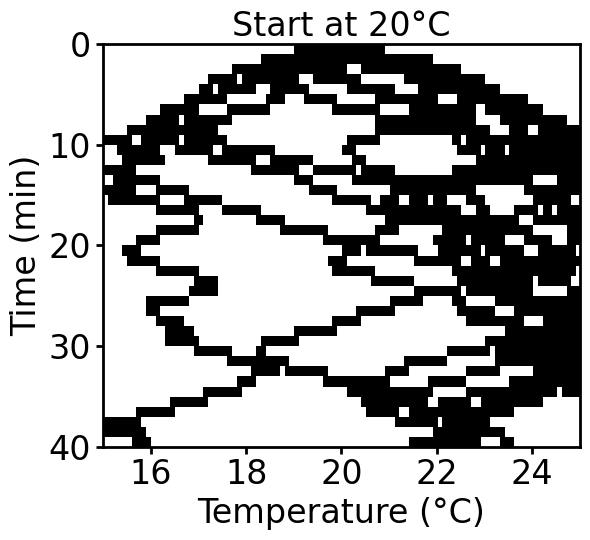

In [6]:
# ============================================================
# Re-run simulation with 15 worms starting at 20°C only,
# then make the occupancy plot
# ============================================================

N_WORMS_old = N_WORMS
N_WORMS = 15

# ---- rerun simulation with only 15 worms
np.random.seed(10)
res_steep_20_15 = simulate_assay_from_config(assay_steep_20)

# ---- restore original value
N_WORMS = N_WORMS_old


# ============================================================
# CLEAN occupancy plot (thresholded)
# ============================================================

def build_temp_time_occupancy(res, temp_bin_width=0.1, time_bin_min=2.0):
    assay = res["assay"]
    tracks = res["tracks"]

    all_temp = []
    all_time = []

    for tr in tracks:
        x = np.asarray(tr["x"], dtype=float)
        t_min = np.arange(len(x)) * DT / 60.0
        temp = temp_from_x(x, assay)

        all_temp.append(temp)
        all_time.append(t_min)

    all_temp = np.concatenate(all_temp)
    all_time = np.concatenate(all_time)

    temp_edges = np.arange(
        assay["T_left"],
        assay["T_right"] + temp_bin_width,
        temp_bin_width
    )

    time_edges = np.arange(0, 40 + time_bin_min, time_bin_min)

    H, _, _ = np.histogram2d(
        all_temp, all_time,
        bins=[temp_edges, time_edges]
    )

    H = H.T  # time x temp

    return H, temp_edges, time_edges


def plot_temp_time_hist_clean(ax, res, panel_title,
                              temp_bin_width=0.1,
                              time_bin_min=1.0,
                              percentile_thresh=85):

    H, temp_edges, time_edges = build_temp_time_occupancy(
        res,
        temp_bin_width=temp_bin_width,
        time_bin_min=time_bin_min
    )

    H_norm = H / (np.max(H) + 1e-9)

    if np.any(H_norm > 0):
        thresh = np.percentile(H_norm[H_norm > 0], percentile_thresh)
        occ = H_norm >= thresh
    else:
        occ = np.zeros_like(H_norm, dtype=bool)

    ax.imshow(
        occ,
        cmap="binary",
        interpolation="nearest",
        aspect="auto",
        origin="upper",
        extent=[temp_edges[0], temp_edges[-1], time_edges[-1], time_edges[0]]
    )

    ax.set_title(panel_title, fontsize=24)
    ax.set_xlabel("Temperature (°C)", fontsize=24)
    ax.set_ylabel("Time (min)", fontsize=24)

    ax.set_xlim(res["assay"]["T_left"], res["assay"]["T_right"])
    ax.set_ylim(40, 0)

    ax.set_xticks([16, 18, 20, 22, 24])
    ax.set_yticks([0, 10, 20, 30, 40])

    ax.tick_params(axis="both", labelsize=24, width=2, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2)


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))

input_threshold = 0

plot_temp_time_hist_clean(
    ax, res_steep_20_15, "Start at 20°C",
    percentile_thresh=input_threshold
)

plt.tight_layout()

if save_fig:
    save_path = save_folder + "simulation_steep_20_histogram_15worms.svg"
    plt.savefig(save_path, format="svg", bbox_inches="tight")
    print(f"Figure saved to: {save_path}")

plt.show()